# 03 — Q-Learning Dynamic Pricing Agent

This notebook defines the reinforcement-learning environment, discretizes continuous market states, trains a tabular Q-learning agent, and saves the learned Q-table.

**Outputs written to `artifacts/`:**

- `q_learning_artifacts.joblib`
- `training_rewards.csv`

Run notebooks 01 and 02 first.

## 1. Imports and training artifacts

In [1]:
from pathlib import Path
import json
import random
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'dynamic_pricing.csv').exists() and (PROJECT_ROOT.parent / 'dynamic_pricing.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)
print(f'Project root: {PROJECT_ROOT.resolve()}')

from collections import defaultdict

Project root: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Artificial Intellegence Driven Decision Making\CA2 Project


In [2]:
required = [
    'train_features.csv', 'train_environment_costs.csv',
    'random_forest_revenue_model.joblib'
]
missing = [name for name in required if not (ARTIFACT_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f'Run notebooks 01 and 02 first. Missing: {missing}')

X_train = pd.read_csv(ARTIFACT_DIR / 'train_features.csv')
train_base_cost = pd.read_csv(
    ARTIFACT_DIR / 'train_environment_costs.csv'
)['predicted_base_cost'].to_numpy()

print(f'Training market states: {X_train.shape}')
print(f'Environment base-cost predictions: {train_base_cost.shape}')

Training market states: (800, 12)
Environment base-cost predictions: (800,)


## 2. RL formulation

**State:** riders (demand), drivers (supply), demand/supply ratio, expected duration, customer ride history, rating, loyalty, location, booking time, and vehicle type.

**Actions:** discrete price multipliers `[0.8, 0.9, 1.0, 1.1, 1.2, 1.3]`.

For model-estimated historical/base cost $C$ and multiplier $m$:

$$\text{adjusted price}=C\times m$$

High prices reduce retained demand through an elasticity function. Customers are moderately less price-sensitive when demand exceeds supply. A quadratic penalty discourages multipliers above 1.1:

$$\text{reward}=(\text{adjusted price}\times\text{retained demand})-\text{penalty}$$

In [3]:
ACTIONS = np.array([0.8, 0.9, 1.0, 1.1, 1.2, 1.3])
PRICE_ELASTICITY = 1.35
EXCESS_PENALTY_WEIGHT = 8.0

def pricing_outcome(base_cost, multiplier, demand_supply_ratio):
    adjusted_price = float(base_cost) * float(multiplier)
    pressure = float(np.clip(demand_supply_ratio, 0.5, 3.0))
    local_elasticity = PRICE_ELASTICITY / np.sqrt(pressure)
    retained_demand = np.exp(-local_elasticity * (float(multiplier) - 1.0))
    retained_demand = float(np.clip(retained_demand, 0.45, 1.10))

    expected_revenue = adjusted_price * retained_demand
    excess = max(0.0, float(multiplier) - 1.10)
    penalty = float(base_cost) * EXCESS_PENALTY_WEIGHT * (excess ** 2)
    reward = expected_revenue - penalty
    return adjusted_price, retained_demand, expected_revenue, penalty, reward

examples = []
for multiplier in ACTIONS:
    examples.append([multiplier, *pricing_outcome(100, multiplier, 1.0)])
display(pd.DataFrame(examples, columns=[
    'multiplier', 'adjusted_price', 'retained_demand',
    'expected_revenue', 'penalty', 'reward'
]).round(3))

,multiplier,adjusted_price,retained_demand,expected_revenue,penalty,reward
0,0.8,80.0,1.100,88.000,0.0,88.000
1,0.9,90.0,1.100,99.000,0.0,99.000
2,1.0,100.0,1.000,100.000,0.0,100.000
3,1.1,110.0,0.874,96.109,0.0,96.109
4,1.2,120.0,0.763,91.606,8.0,83.606
5,1.3,130.0,0.667,86.707,32.0,54.707


## 3. Discretize the state

Q-tables require discrete state keys, so continuous fields use coarse quantile bins learned from training data. Categorical values are converted to integer codes. Coarse bins reduce sparsity in this small dataset.

In [4]:
categorical_features = [
    'location_category', 'customer_loyalty_status',
    'time_of_booking', 'vehicle_type'
]
state_numeric_bins = {
    'number_of_riders': 2,
    'number_of_drivers': 2,
    'demand_supply_ratio': 3,
    'expected_ride_duration': 2,
    'number_of_past_rides': 2,
    'average_ratings': 2,
}

def learn_bin_edges(series, n_bins):
    quantiles = np.linspace(0, 1, n_bins + 1)[1:-1]
    return np.unique(series.quantile(quantiles).to_numpy(dtype=float))

bin_edges = {
    column: learn_bin_edges(X_train[column], n_bins)
    for column, n_bins in state_numeric_bins.items()
}
category_maps = {
    column: {
        value: i for i, value in enumerate(
            sorted(X_train[column].dropna().unique())
        )
    }
    for column in categorical_features
}

def row_to_state(row):
    numeric_state = tuple(
        int(np.digitize(float(row[column]), bin_edges[column]))
        for column in state_numeric_bins
    )
    categorical_state = tuple(
        category_maps[column].get(row[column], -1)
        for column in categorical_features
    )
    return numeric_state + categorical_state

train_states = [row_to_state(row) for _, row in X_train.iterrows()]
print(f'State dimensions: {len(train_states[0])}')
print(f'Unique training states: {len(set(train_states))}')

State dimensions: 10
Unique training states: 730


## 4. Q-learning agent

The agent uses a learning rate, discount factor, epsilon-greedy exploration, and epsilon decay. Each dataset row is an independent market snapshot, so it is treated as a terminal transition. The discount factor is retained in the standard Q-learning implementation for future sequential extensions.

In [5]:
class QLearningPricingAgent:
    def __init__(self, n_actions, learning_rate=0.12, discount_factor=0.90,
                 epsilon=1.0, epsilon_decay=0.97, min_epsilon=0.05):
        self.n_actions = n_actions
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.q_table = defaultdict(lambda: np.zeros(n_actions, dtype=float))

    def choose_action(self, state, explore=True):
        if explore and np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        q_values = self.q_table[state]
        best_actions = np.flatnonzero(np.isclose(q_values, q_values.max()))
        return int(np.random.choice(best_actions))

    def update(self, state, action, reward, next_state, done=False):
        current_q = self.q_table[state][action]
        future_q = 0.0 if done else np.max(self.q_table[next_state])
        target = reward + self.discount_factor * future_q
        self.q_table[state][action] += self.learning_rate * (target - current_q)

    def decay_exploration(self):
        self.epsilon = max(
            self.min_epsilon, self.epsilon * self.epsilon_decay
        )

## 5. Train over multiple episodes

In [6]:
N_EPISODES = 180
agent = QLearningPricingAgent(n_actions=len(ACTIONS))
episode_rewards = []
epsilon_history = []
train_ratios = X_train['demand_supply_ratio'].to_numpy()

for episode in range(N_EPISODES):
    order = np.random.permutation(len(X_train))
    total_episode_reward = 0.0

    for position in order:
        state = train_states[position]
        action = agent.choose_action(state, explore=True)
        multiplier = ACTIONS[action]
        *_, reward = pricing_outcome(
            train_base_cost[position], multiplier, train_ratios[position]
        )

        # Independent market observations are terminal contextual decisions.
        agent.update(state, action, reward, state, done=True)
        total_episode_reward += reward

    episode_rewards.append(total_episode_reward)
    epsilon_history.append(agent.epsilon)
    agent.decay_exploration()

print(f'Trained for {N_EPISODES} episodes.')
print(f'Q-table contains {len(agent.q_table)} states.')
print(f'Final epsilon: {agent.epsilon:.3f}')

Trained for 180 episodes.
Q-table contains 730 states.
Final epsilon: 0.050


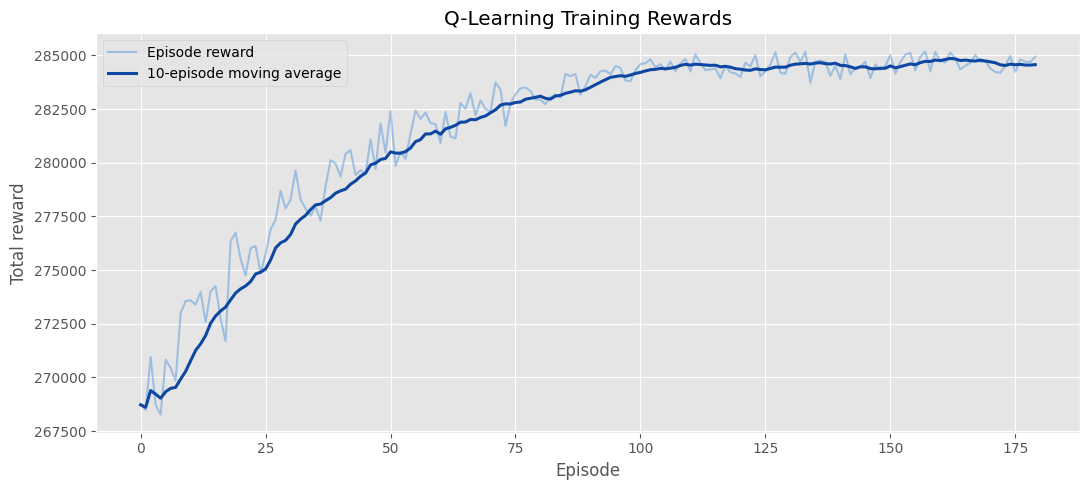

In [7]:
reward_series = pd.Series(episode_rewards)
moving_average = reward_series.rolling(10, min_periods=1).mean()

plt.figure(figsize=(11, 5))
plt.plot(reward_series, alpha=0.35, color='#1976D2', label='Episode reward')
plt.plot(moving_average, color='#0D47A1', linewidth=2.2,
         label='10-episode moving average')
plt.title('Q-Learning Training Rewards')
plt.xlabel('Episode')
plt.ylabel('Total reward')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Save the learned policy

In [8]:
q_table_plain = {state: values.copy() for state, values in agent.q_table.items()}
known_q_values = np.vstack(list(q_table_plain.values()))
fallback_action = int(np.argmax(known_q_values.mean(axis=0)))

rl_artifacts = {
    'actions': ACTIONS,
    'q_table': q_table_plain,
    'fallback_action': fallback_action,
    'bin_edges': bin_edges,
    'category_maps': category_maps,
    'state_numeric_columns': list(state_numeric_bins.keys()),
    'categorical_columns': categorical_features,
    'price_elasticity': PRICE_ELASTICITY,
    'excess_penalty_weight': EXCESS_PENALTY_WEIGHT,
    'learning_rate': agent.learning_rate,
    'discount_factor': agent.discount_factor,
    'final_epsilon': agent.epsilon,
}
joblib.dump(rl_artifacts, ARTIFACT_DIR / 'q_learning_artifacts.joblib')

pd.DataFrame({
    'episode': np.arange(1, N_EPISODES + 1),
    'total_reward': episode_rewards,
    'epsilon': epsilon_history,
    'moving_average_10': moving_average
}).to_csv(ARTIFACT_DIR / 'training_rewards.csv', index=False)

print(f'Saved Q-learning policy to: {ARTIFACT_DIR / "q_learning_artifacts.joblib"}')
print(f'Fallback multiplier for unseen states: {ACTIONS[fallback_action]:.1f}')

Saved Q-learning policy to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Artificial Intellegence Driven Decision Making\CA2 Project\artifacts\q_learning_artifacts.joblib
Fallback multiplier for unseen states: 1.1


## Stage complete

Q-learning training is complete. Continue with **04_pricing_policy_evaluation.ipynb**.